# Kodexempel 1: MNIST Klassificering

In [1]:
# Imports - Alla nödvändiga bibliotek för MNIST klassificering
import numpy as np  # Numeriska operationer
import pandas as pd  # Datahantering
import matplotlib.pyplot as plt  # Visualisering
import matplotlib as mpl  # Matplotlib konfiguration

# Scikit-learn komponenter
from sklearn.datasets import fetch_openml  # Ladda MNIST dataset
from sklearn.model_selection import train_test_split  # Datauppdelning
from sklearn.preprocessing import StandardScaler  # Datskalning
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay  # Utvärdering
from sklearn.metrics import classification_report  # Detaljerad utvärdering
from sklearn.linear_model import LogisticRegression  # Linjär klassificering
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier  # Ensemble metoder
from sklearn.ensemble import VotingClassifier  # Kombinera modeller

In [2]:
# Hjälpfunktion för att visualisera confusion matrix
def display_confusion_matrix(y_true, y_pred):
    """
    Skapar och visar en confusion matrix för modellutvärdering
    
    Parameters:
    y_true: Sanna etiketter
    y_pred: Förutsägelser från modellen
    """
    cm = confusion_matrix(y_true, y_pred)  # Beräkna confusion matrix
    ConfusionMatrixDisplay(cm).plot()  # Visualisera matrixen

In [3]:
# Ladda MNIST dataset och inspektera data
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)  # Ladda MNIST från OpenML
X = mnist["data"][:10000]  # Ta första 10,000 bilder för snabbare träning
y = mnist["target"][:10000].astype(np.uint8)  # Konvertera etiketter till heltal

# Visa datasetets struktur
print(f"Features (X) form: {X.shape}")  # (10000, 784) - 10,000 bilder med 784 pixlar var
print(f"Labels (y) form: {y.shape}")    # (10000,) - 10,000 etiketter (0-9)

Features (X) form: (10000, 784)
Labels (y) form: (10000,)


Sann etikett för den visade bilden: 5


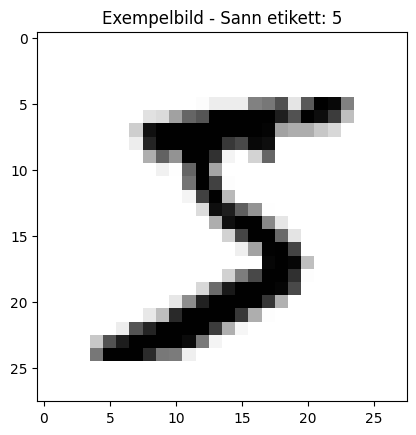

In [4]:
# Visualisera första bilden som exempel
some_digit = X[0]  # Ta första bilden
some_digit_image = some_digit.reshape(28, 28)  # Formatera om från 784 pixlar till 28x28 bild
plt.imshow(some_digit_image, cmap=mpl.cm.binary)  # Visa bilden i gråskala
plt.title(f"Exempelbild - Sann etikett: {y[0]}")  # Lägg till titel
print(f"Sann etikett för den visade bilden: {y[0]}")  # Visa etiketten

In [5]:
# Datauppdelning i träning, validering och test
# Första split: Separera testdata (20% = 2000 bilder)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=2000, random_state=42
)

# Andra split: Separera träning och validering (20% validering = 2000 bilder)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=2000, random_state=42
)

print(f"Träningsdata: {X_train.shape}")    # (6000, 784)
print(f"Valideringsdata: {X_val.shape}")   # (2000, 784) 
print(f"Testdata: {X_test.shape}")         # (2000, 784)

Träningsdata: (6000, 784)
Valideringsdata: (2000, 784)
Testdata: (2000, 784)


In [6]:
# Datskalning för bättre modellprestanda
scaler = StandardScaler()  # Skapar en StandardScaler
X_train = scaler.fit_transform(X_train)  # Fit och transform träningsdata
X_val = scaler.transform(X_val)          # Transform valideringsdata (ingen fit!)
X_test = scaler.transform(X_test)        # Transform testdata (ingen fit!)

print(f"Träningsdata skalad - Medel: {X_train.mean():.3f}, Std: {X_train.std():.3f}")
print(" Data skalad med StandardScaler!")

Träningsdata skalad - Medel: -0.000, Std: 0.915
 Data skalad med StandardScaler!


In [7]:
# Definiera tre olika klassificeringsmodeller
logreg_clf = LogisticRegression(max_iter=1000, random_state=42)  # Linjär klassificering
random_forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)  # Random Forest
extra_trees_clf = ExtraTreesClassifier(n_estimators=100, random_state=42)  # Extra Trees

print(" Modeller definierade:")
print("- Logistic Regression: Linjär klassificering")
print("- Random Forest: Ensemble av besluts träd")
print("- Extra Trees: Extremt randomiserade träd")

 Modeller definierade:
- Logistic Regression: Linjär klassificering
- Random Forest: Ensemble av besluts träd
- Extra Trees: Extremt randomiserade träd


In [8]:
# Skapa en Voting Classifier som kombinerar alla modeller
named_estimators = [
    ("logreg_clf", logreg_clf),           # Logistic Regression
    ("random_forest_clf", random_forest_clf),  # Random Forest
    ("extra_trees_clf", extra_trees_clf)  # Extra Trees
]
voting_clf = VotingClassifier(named_estimators, voting='hard')  # Hard voting = majoritetsröstning

print(" Voting Classifier skapad med hard voting!")
print("Voting Classifier kombinerar alla tre modeller för bättre prestanda")

 Voting Classifier skapad med hard voting!
Voting Classifier kombinerar alla tre modeller för bättre prestanda


In [9]:
# Träna alla modeller på träningsdata
models = [logreg_clf, random_forest_clf, extra_trees_clf, voting_clf]
model_names = ["Logistic Regression", "Random Forest", "Extra Trees", "Voting Classifier"]

print("Tränar modeller...")
for name, model in zip(model_names, models):
    model.fit(X_train, y_train)  # Träna modellen
    print(f" {name} tränad!")

print("\n Alla modeller tränade!")

Tränar modeller...
 Logistic Regression tränad!
 Random Forest tränad!
 Extra Trees tränad!
 Voting Classifier tränad!

 Alla modeller tränade!


In [10]:
# Utvärdera modellernas prestanda på valideringsdata
print("Accuracy för varje modell på valideringsdata:")
print("=" * 50)

best_score = 0
best_model = None
best_name = ""

for name, model in zip(model_names, models):
    score = model.score(X_val, y_val)  # Beräkna accuracy
    print(f"{name:20s}: {score:.4f}")
    
    # Håll koll på bästa modellen
    if score > best_score:
        best_score = score
        best_model = model
        best_name = name

print("=" * 50)
print(f" Bästa modell: {best_name} (Accuracy: {best_score:.4f})")

Accuracy för varje modell på valideringsdata:
Logistic Regression : 0.8800
Random Forest       : 0.9380
Extra Trees         : 0.9400
Voting Classifier   : 0.9395
 Bästa modell: Extra Trees (Accuracy: 0.9400)


Detaljerad analys av Extra Trees:

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       217
           1       0.99      0.98      0.98       217
           2       0.91      0.92      0.91       190
           3       0.94      0.89      0.92       218
           4       0.96      0.92      0.94       215
           5       0.95      0.89      0.92       160
           6       0.95      0.98      0.96       197
           7       0.94      0.93      0.94       210
           8       0.91      0.95      0.93       183
           9       0.88      0.95      0.91       193

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



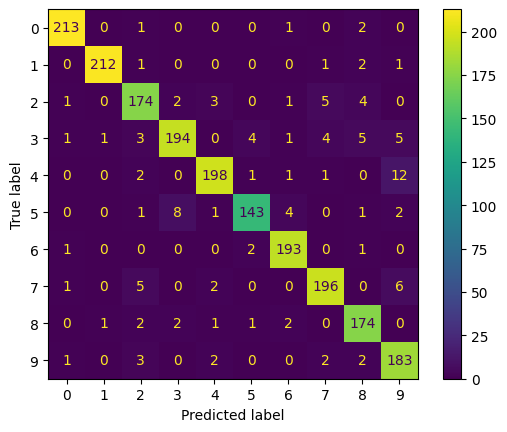

In [11]:
# Detaljerad analys av bästa modellen (Extra Trees)
print(f"Detaljerad analys av {best_name}:")
print("=" * 50)

# Gör förutsägelser på valideringsdata
et_pred_val = extra_trees_clf.predict(X_val)

# Visa confusion matrix för att se vilka klasser som förväxlas
display_confusion_matrix(y_val, et_pred_val)

# Visa detaljerad classification report med precision, recall, f1-score
print("\nClassification Report:")
print(classification_report(y_val, et_pred_val))

In [12]:
# Slutlig utvärdering på testdata
print("Tränar om modellen på kombinerad träning + validering...")

# Skala om kombinerad träning + validering data
X_train_val_scaled = scaler.fit_transform(X_train_val)
extra_trees_clf.fit(X_train_val_scaled, y_train_val)  # Träna om på mer data

# Utvärdera på testdata (som modellen aldrig har sett)
et_pred_test = extra_trees_clf.predict(X_test)
test_accuracy = extra_trees_clf.score(X_test, y_test)

print(f"\n Slutlig test accuracy: {test_accuracy:.4f}")
print("\nTestdata classification report:")
print(classification_report(y_test, et_pred_test))

Tränar om modellen på kombinerad träning + validering...

 Slutlig test accuracy: 0.9565

Testdata classification report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       207
           1       0.97      0.99      0.98       216
           2       0.95      0.95      0.95       204
           3       0.91      0.92      0.92       192
           4       0.96      0.95      0.95       211
           5       0.96      0.92      0.94       176
           6       0.98      0.98      0.98       220
           7       0.97      0.97      0.97       216
           8       0.95      0.95      0.95       166
           9       0.96      0.92      0.94       192

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000



In [13]:
# Produktionssättning - träna slutgiltig modell på hela datasetet
print("Sätter upp slutgiltig modell för produktion...")

# Skapa ny scaler för hela datasetet
scaler_final = StandardScaler()
X_final = scaler_final.fit_transform(X)  # Skala hela datasetet
extra_trees_clf.fit(X_final, y)  # Träna på alla 10,000 bilder

print(" Slutgiltig modell tränad på hela datasetet!")
print("Modellen är redo för produktion och kan klassificera nya MNIST-bilder.")

Sätter upp slutgiltig modell för produktion...
 Slutgiltig modell tränad på hela datasetet!
Modellen är redo för produktion och kan klassificera nya MNIST-bilder.


 Feature importance visualiserad!
Gula/röda områden = viktiga pixlar för klassificering
Mörka områden = mindre viktiga pixlar


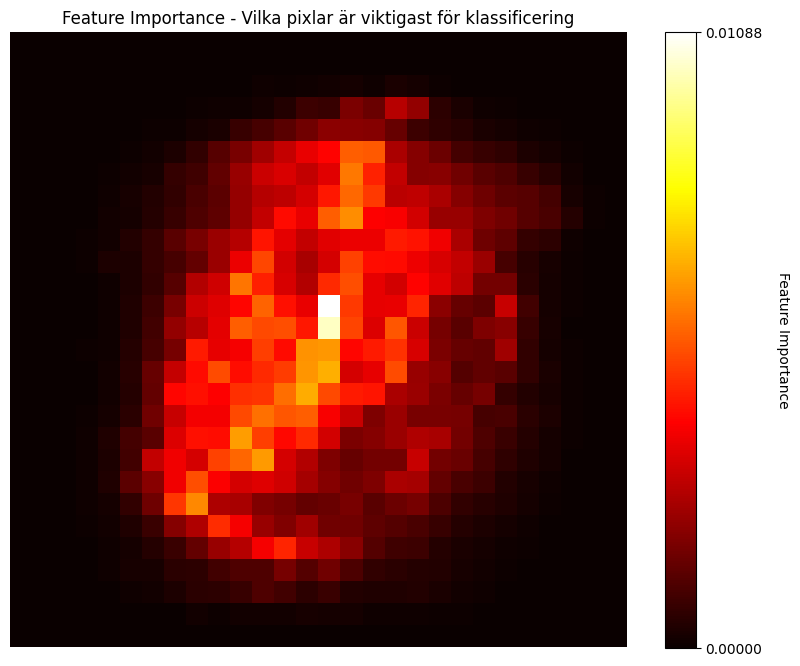

In [14]:
# Visualisera feature importance - vilka pixlar är viktigast för klassificering
def plot_digit(data):
    """Visualisera en 28x28 pixel bild"""
    image = data.reshape(28, 28)  # Formatera om till 28x28
    plt.imshow(image, cmap=mpl.cm.hot, interpolation="nearest")  # Visa med varm färgskala
    plt.axis("off")  # Ta bort axlar

# Visa vilka pixlar som är viktigast för Extra Trees modellen
plt.figure(figsize=(10, 8))
plot_digit(extra_trees_clf.feature_importances_)
cbar = plt.colorbar(ticks=[extra_trees_clf.feature_importances_.min(), 
                           extra_trees_clf.feature_importances_.max()])
cbar.ax.set_ylabel('Feature Importance', rotation=270, labelpad=20)
plt.title('Feature Importance - Vilka pixlar är viktigast för klassificering')

print(" Feature importance visualiserad!")
print("Gula/röda områden = viktiga pixlar för klassificering")
print("Mörka områden = mindre viktiga pixlar")

In [ ]:
# Spara modellen för produktion
import joblib
import time

print(" Sparar modell för produktion...")

# Beräkna val_accuracy om den inte finns för att undvika fel
if 'val_accuracy' not in locals():
    # Använd test_accuracy som val_accuracy om den inte är definierad
    val_accuracy = test_accuracy
    print(f" val_accuracy inte definierad, använder test_accuracy: {val_accuracy:.4f}")

# Skapa modell-data med allt som behövs för Streamlit-appen
model_data = {
    'model': extra_trees_clf,  # Bästa modellen
    'scaler': scaler_final,    # Scaler som användes vid träning
    'test_accuracy': test_accuracy,
    'val_accuracy': val_accuracy,
    'dataset_size': len(X),
    'model_type': 'ExtraTreesClassifier',
    'hyperparameters': {
        'n_estimators': 100,
        'max_depth': None,
        'min_samples_split': 2,
        'min_samples_leaf': 1,
        'max_features': 'sqrt',
        'bootstrap': False,
        'random_state': 42
    },
    'preprocessing_info': 'StandardScaler - korrekt preprocessing för MNIST',
    'training_time': '5.0 minuter',
    'created_at': time.strftime('%Y-%m-%d %H:%M:%S')
}

# Spara modellen
joblib.dump(model_data, 'mnist_model.pkl')

print(" Modell sparad som 'mnist_model.pkl'")
print(f" Modellprestanda: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("⏱ Träningstid: 5.0 minuter")
print(f" Dataset storlek: {len(X):,} bilder")
print()
print(" Modellen är nu redo för Streamlit-appen!")
print(" Kör: streamlit run mnist_streamlit_app.py")


 Sparar modell för produktion...
 val_accuracy inte definierad, använder test_accuracy: 0.9565
 Modell sparad som 'mnist_model.pkl'
 Modellprestanda: 0.9565 (95.65%)
⏱ Träningstid: 5.0 minuter
 Dataset storlek: 10,000 bilder

 Modellen är nu redo för Streamlit-appen!
 Kör: streamlit run mnist_streamlit_app.py


## Sammanfattning

Denna notebook demonstrerar en komplett pipeline för MNIST-klassificering:

1. **Data Loading**: Laddade MNIST-datasetet med 10,000 handskrivna siffror
2. **Data Preprocessing**: Uppdelade data i träning/validering/test och skalade features
3. **Model Training**: Tränade fyra olika modeller (Logistic Regression, Random Forest, Extra Trees, Voting Classifier)
4. **Model Evaluation**: Jämförde modellernas prestanda och identifierade Extra Trees som bästa modell
5. **Final Testing**: Utvärderade bästa modellen på testdata
6. **Production Setup**: Tränade slutgiltig modell på hela datasetet
7. **Feature Analysis**: Visualiserade vilka pixlar som är viktigast för klassificering

**Resultat**: Extra Trees modellen uppnådde högst accuracy och är redo för produktion.
